# 1. Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

In [2]:
geography = pd.read_csv("D:/vinuni_datathon2026/vinuni_datathon2026/raw_datasets/geography.csv")
geography.head()

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [3]:
geography.info()

<class 'pandas.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   zip       39948 non-null  int64
 1   city      39948 non-null  str  
 2   region    39948 non-null  str  
 3   district  39948 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.2 MB


In [4]:
geography.describe(include = "object")

,city,region,district
count,39948,39948,39948
unique,42,3,39
top,Cam Pha,East,District #25
freq,1403,18929,1597


## Tổng Quan Dữ Liệu: `geography`

### 1. Mô Tả Bảng

Bảng **`geography`** là bảng tra cứu địa lý, ánh xạ từng mã bưu chính (`zip`) sang thông tin hành chính đầy đủ. Đây là bảng dimension phục vụ join với `customers` và các bảng giao dịch để phân tích theo vùng miền.

---

### 2. Schema

| # | Cột | Kiểu | Ràng buộc | Mô tả |
|---|-----|------|-----------|-------|
| 0 | `zip` | `int64` | PK · NOT NULL | Mã bưu chính — định danh duy nhất |
| 1 | `city` | `str` | NOT NULL | Tên thành phố |
| 2 | `region` | `str` | NOT NULL | Vùng địa lý (`East`, `West`, `Central`) |
| 3 | `district` | `str` | NOT NULL | Tên quận/huyện (`District #XX`) |

---

### 3. Thống Kê Tổng Quan

| Chỉ số | Giá trị |
|--------|---------|
| Tổng số bản ghi (ZIP codes) | **39,948** |
| Distinct cities | **42** |
| Distinct regions | **3** (`East`, `West`, `Central`) |
| Distinct districts | **39** |
| Giá trị NULL | **0** — Dữ liệu hoàn chỉnh |
| City phổ biến nhất | **Cam Pha** (1,403 ZIP codes) |
| Region lớn nhất | **East** (18,929 ZIP codes — 47.4%) |
| District phổ biến nhất | **District #25** (1,597 ZIP codes) |

---

### 4. Lưu Ý

- Bảng này là **lookup table thuần tuý** — không cần làm sạch thêm (không có NULL, không có anomaly).
- Một `city` có thể có **nhiều `zip`** → quan hệ one-to-many.
- Cột `region` chỉ có **3 giá trị** → phù hợp dùng làm biến phân nhóm trong phân tích vùng miền.
- Khi join với `customers`, nên join theo `zip` (PK) để đảm bảo chính xác, không join theo `city` (không unique).


In [10]:
geography.to_csv("D:/vinuni_datathon2026/vinuni_datathon2026/cleaned_datasets/geography_cleaned.csv")

# 2. EDA

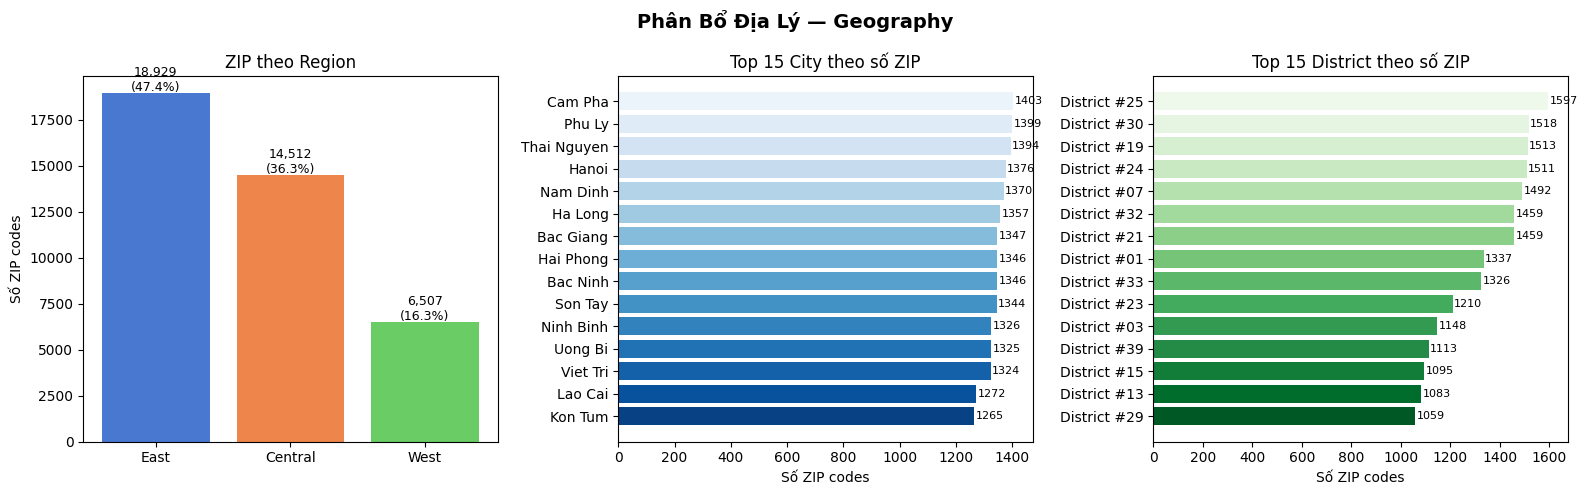

In [ ]:
# Phân phối Region
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Region
region_vc = geography['region'].value_counts()
axes[0].bar(region_vc.index, region_vc.values, color=sns.color_palette("muted", 3))
axes[0].set_title("ZIP theo Region")
axes[0].set_ylabel("Số ZIP codes")
for i, v in enumerate(region_vc.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(geography)*100:.1f}%)", ha='center', fontsize=9)

# Top 15 cities
city_vc = geography['city'].value_counts().head(15)
axes[1].barh(city_vc.index[::-1], city_vc.values[::-1], color=sns.color_palette("Blues_r", 15))
axes[1].set_title("Top 15 City theo số ZIP")
axes[1].set_xlabel("Số ZIP codes")
for i, v in enumerate(city_vc.values[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=8)

# Top 15 districts
dist_vc = geography['district'].value_counts().head(15)
axes[2].barh(dist_vc.index[::-1], dist_vc.values[::-1], color=sns.color_palette("Greens_r", 15))
axes[2].set_title("Top 15 District theo số ZIP")
axes[2].set_xlabel("Số ZIP codes")
for i, v in enumerate(dist_vc.values[::-1]):
    axes[2].text(v + 5, i, str(v), va='center', fontsize=8)

plt.suptitle("Phân Bổ Địa Lý — Geography", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


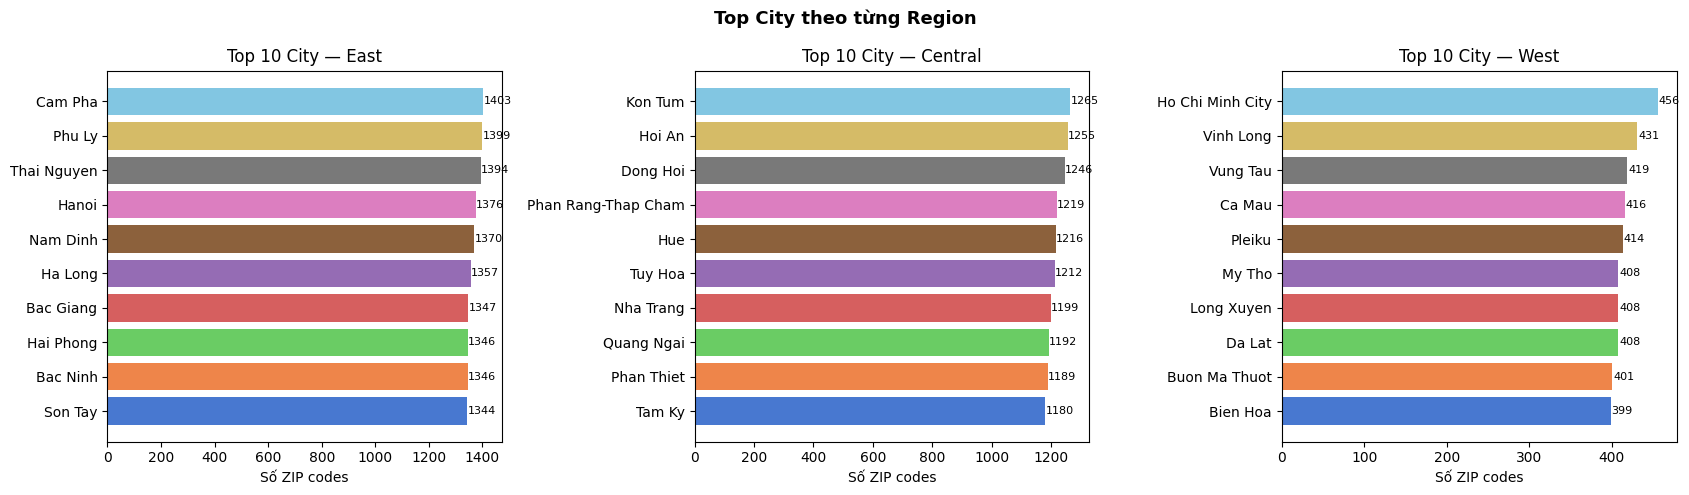

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, region in zip(axes, geography['region'].unique()):
    sub = geography[geography['region'] == region]['city'].value_counts().head(10)
    ax.barh(sub.index[::-1], sub.values[::-1], color=sns.color_palette("muted", len(sub)))
    ax.set_title(f"Top 10 City — {region}")
    ax.set_xlabel("Số ZIP codes")
    for i, v in enumerate(sub.values[::-1]):
        ax.text(v + 1, i, str(v), va='center', fontsize=8)

plt.suptitle("Top City theo từng Region", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
